## Decision Tree (CART Algorithm)

Supervised learning

Non Parametric method

A Rule based learning or Heuristic approach

Useful for both Classification and regression

- CART uses **binary trees**.
- It uses **not only the important feature at the top of the tree, but also the best split point for the feature**, allowing the depth to be made smaller.
- It is **suitable for ensemble techniques** that use many small trees.
- However, the CART algorithm **may not be suitable for categorical features.** In particular, it is not very good for nominal categorical data, such as [‘red’, ‘green’, ‘blue’].
  - In order to use CART, categorical data must be **converted to numeric type in advance.**
- On the other hand, CART can **precisely process continuous** numerical data.

## Introduction

A decision tree is **an inverted tree-like structure that mimics human decision-making by asking a series of questions (decision-making as a checklist
of questions).** It works by **recursively splitting data into subsets until a final decision or prediction** is reached at the leaf nodes.
- Decision trees **divide the feature space into axis parallel rectangles.**
- Decision trees are **highly interpretable models that closely resemble the human decision-making process i.e., it asks a series of questions in a nested if-then-else structure.** Their intuitive structure makes them particularly effective for handling categorical data.
- Unlike algorithms such as logistic regression or support vector machines (SVMs), which focus on learning linear relationships, **decision trees excel at capturing complex, non-linear patterns in data**.
- Many data sets in **real world are not linearly separable!**. There are two options to deal with it:
  - Use non-linear features(Polynomial features), and **train a linear classifier in the transformed non-linear feature space**
  - Use non-linear classifiers, like Decision tree. **Decision Trees can handle nonlinear separable data sets** and are one of the most popular classifiers

- A key strength of decision trees lies in their **ability to clearly illustrate the factors that lead to a particular prediction**, making them valuable tools for explaining business decisions to stakeholders.

- Furthermore, decision trees serve as the **foundation for more advanced ensemble methods**, such as random forests, which are widely popular in competitive data science platforms like Kaggle.

### Toy problem

Build a system that suggests whether a user is likely to enjoy a particular restaurant based on their previous visits. For each visit, you record two pieces of information:
1. the average cost of the meal $x_1$ and
2. how spicy the user rated the food on a chosen scale $x_2$.

The target label for each visit is whether the user liked the food (+1) or did not like it (-1). The goal is to learn a model that uses $x_1$ and $x_2$ to predict future “like” or “dislike” outcomes and thereby recommend suitable restaurants.

In [ ]:
%%writefile data.csv
cost,spicy,target
50,4,1
50,7,-1
50,9,1
75,2,1
100,3,1
150,1,1
150,3,1
150,6,-1
150,10,1
225,9,1
250,1,-1
250,4,1
250,7,-1
300,4.5,1
300,6,-1
300,9,1
350,2,-1
350,3,1
400,8,-1
425,4,1
450,1,-1
450,7,-1
475,3.5,1
500,9,-1

Writing data.csv


In [ ]:
import pandas as pd
data = pd.read_csv('/content/data.csv')
data

,cost,spicy,target
0,50,4.0,1
1,50,7.0,-1
2,50,9.0,1
3,75,2.0,1
4,100,3.0,1
5,150,1.0,1
6,150,3.0,1
7,150,6.0,-1
8,150,10.0,1
9,225,9.0,1


<Axes: xlabel='cost', ylabel='spicy'>

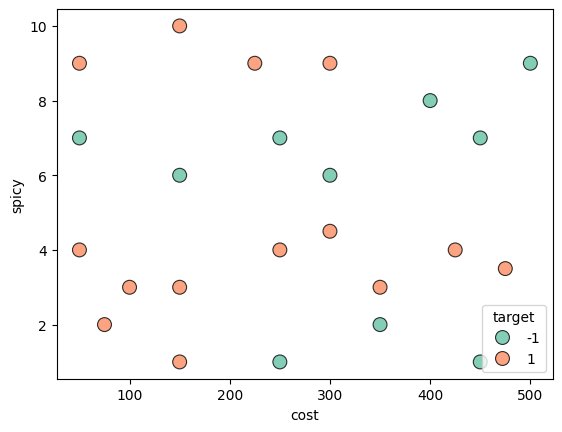

In [ ]:
sns.scatterplot(data = data, x = 'cost', y = 'spicy', hue = 'target', palette='Set2', s=100, alpha=0.8, edgecolor='black', linewidth=0.8)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier()
dt

DecisionTreeClassifier()

In [ ]:
X = data.drop('target', axis = 1)
y = data['target']

In [ ]:
dt.fit(X, y)

DecisionTreeClassifier()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

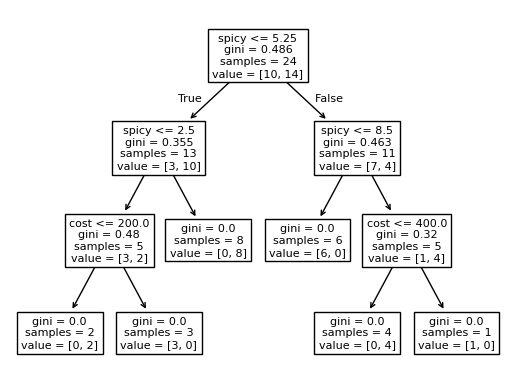

In [ ]:
plot_tree(dt, feature_names = X.columns)
plt.show()

In [ ]:
import seaborn as sns

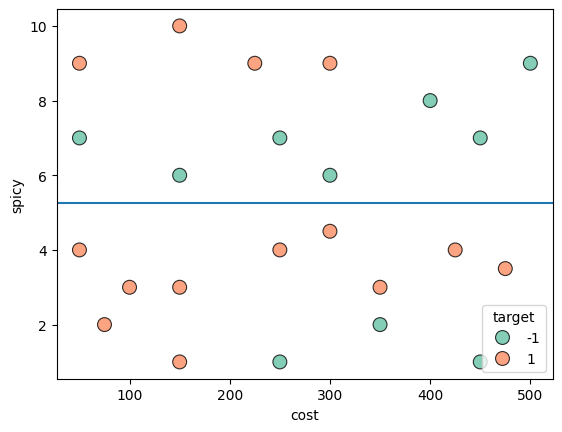

In [ ]:
sns.scatterplot(data = data, x = 'cost', y = 'spicy', hue = 'target', palette='Set2', s=100, alpha=0.8, edgecolor='black', linewidth=0.8)
plt.axhline(y = 5.25)

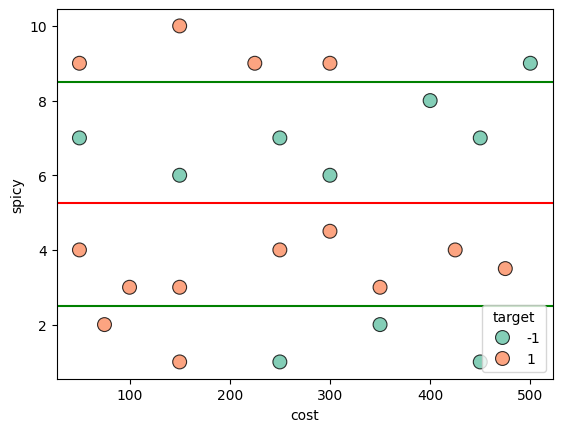

In [ ]:
sns.scatterplot(data = data, x = 'cost', y = 'spicy', hue = 'target', palette='Set2', s=100, alpha=0.8, edgecolor='black', linewidth=0.8)
plt.axhline(y = 5.25, color = 'r', label = 'root')
plt.axhline(y = 2.5, color = 'g', label = 'level1')
plt.axhline(y = 8.5, color = 'g', label = 'level1')

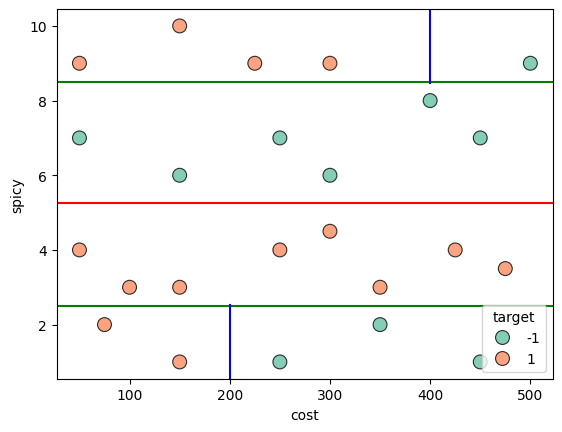

In [ ]:
sns.scatterplot(data = data, x = 'cost', y = 'spicy', hue = 'target', palette='Set2', s=100, alpha=0.8, edgecolor='black', linewidth=0.8)
plt.axhline(y = 5.25, color = 'r', label = 'root')
plt.axhline(y = 2.5, color = 'g', label = 'level1')
plt.axhline(y = 8.5, color = 'g', label = 'level1')
plt.axvline(x = 200, ymin = 0, ymax = 0.20, color = 'b', label = 'level2')
plt.axvline(x = 400, ymin = 0.80, ymax = 1, color = 'b', label = 'level2')

### Decision Tree Traversal


- The **root node** is the topmost node of a decision tree, from which all **splits begin**.
- The **leaf nodes** are the terminal nodes that represent the **final outcome and cannot be split further**. Each leaf node assigns a classification
-  Each **branch** corresponds to **attribute/feature value**, a decision (to choose a path) as a result of the test.
- The nodes that lie between the root and the leaves are called **internal nodes**, where the data is **split based on feature conditions (Rules)** to test an attribute/feature.
  - The **process begins** at the **root node**.
  - At each node, a condition is checked, and the path proceeds left or right based on the outcome. (At every node only binary outcomes are allowed)
  - Each condition is **combined with the previous ones using a logical AND.**
  - Traversal continues until a leaf node is reached. The leaf node represents the final decision, which may be a class label (for classification) or a value (for regression).
    - In classification trees, each leaf node represents a **class label, assigned using majority voting** (the class with the most samples in that leaf becomes the prediction).
    - In regression trees, each **leaf node represents a numerical value, which is the average of all target values in that subset.**

**Backward Traversal and Interpretability**

- In decision trees, you can also traverse the attributes backwards to identify the factors that led to a particular decision.
- **Each decision path can be expressed as a series of IF conditions combined with logical ANDs.**
- The final decisions are stored in the leaf nodes in the form of class labels (for classification tasks).

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, DecisionTreeRegressor

## Problem: Classification

### Classification Problem Formulation: What makes a loan risky?





In [ ]:
%%writefile credit_data.csv
Credit,Term,Income,y
good,3 yrs,high,safe
good,5 yrs,low,risky
good,3 yrs,high,safe
poor,5 yrs,high,risky
poor,3 yrs,low,risky
good,5 yrs,low,safe
poor,3 yrs,high,risky
poor,5 yrs,low,safe
good,3 yrs,high,safe

Overwriting credit_data.csv


In [ ]:
credit_data = pd.read_csv('/content/credit_data.csv')
credit_data

,Credit,Term,Income,y
0,good,3 yrs,high,safe
1,good,5 yrs,low,risky
2,good,3 yrs,high,safe
3,poor,5 yrs,high,risky
4,poor,3 yrs,low,risky
5,good,5 yrs,low,safe
6,poor,3 yrs,high,risky
7,poor,5 yrs,low,safe
8,good,3 yrs,high,safe


In [ ]:
credit_data.groupby(['Credit', 'y'])['y'].count().unstack().T

Credit,good,poor
y,,
risky,1,3
safe,4,1


Given details from a loan application—including the applicant’s credit history, income, loan term, age, marital status, and other relevant financial and personal information—predict whether the loan should be classified as “safe” or “risky.” This classification helps a bank decide whether or not to approve a loan to the applicant.

**Input ($ X $):**  
A vector of features describing each loan applicant, such as:
- Credit history
  - Did I pay previous loans on time? (e.g., excellent, fair, poor)
- Income (numeric)
  - What’s my income?
- Loan term (number of years)
  - How soon do I need to pay the loan?
- Other relevant features
  - Age, reason for the loan, marital status,…

**Output ($ y $):**
- $ y = +1 $: Safe loan (approve)
- $ y = -1 $: Risky loan (do not approve)

### Solution: Intelligent loan application review system


We use a **decision tree classifier** trained on historical loan data. The tree learns to partition the input space based on feature values and sequences of questions corresponding to applicant attributes. At each decision node, the tree checks one feature and branches accordingly.
- **Examples of splits:**
  - If credit history is “excellent,” automatically classify as “safe.”
  - If credit is “fair,” check the loan term. A short term might be “risky,” a longer term might be “safe.”
  - If credit is “poor,” check income next. A high income may still allow the loan to be “safe,” but low income with poor credit is classified as “risky.”

**Training:**  
Fit the decision tree on labeled data where the outcome (safe/risky) is already known.

**Testing or Prediction:**  
Given a new applicant’s data, traverse the decision tree using their feature values to reach a “safe” or “risky” decision.

Such a model allows banks to automate and standardize loan approval processes, ensuring efficient and data-driven decisions based on applicant profiles. Decision trees are particularly useful because their rules are interpretable, making it easy to explain why a loan was approved or denied.

**What does a decision tree represent?**

````
                            Start
                              |
 |-------------------------Credit? ---------------------
 |              |                            |
 |             fair                         poor
 |              |                            |
 |            Term?                       Income?
 |           /     \                     /   |    \
 |      3 years | 5 years             high         Low
 |          |        |                |              |
 |        Risky     Safe            Term?           Risky
 |                                 /      \
 |                        3 years /        \ 5 years
 |                           |                  |
 |                         Risky               Safe
````

- 3 year loans with high income & poor credit history are risky

**What is the prediction for the following query x = (Credit = poor, Income = high, Term = 5 years)?**

- **Input:**  
  $ x_i $ — Feature vector for the $ i $-th loan applicant (e.g., credit, term, income).

- **Model:**  
  $ T(x_i) $ — The decision tree function that takes the applicant’s features and traverses the tree based on learned decision rules.

- **Output:**  
  $ \hat{y}_i = T(x_i) $ — The predicted label for applicant $ i $ (e.g., “Safe” or “Risky”).

$$
\boxed{
\hat{y}_i = T(x_i)
}
$$

Where:
- $ x_i $: input data (applicant features)
- $ T $: decision tree function (model logic)
- $ \hat{y}_i $: predicted outcome



  - **Safe**

#### Training a Decision tree from data

How do we pick the next best feature to place in a
decision tree (to ask a question)?
- Answer: Lowest classification error (GREEDY)

**Goal:**  
Given training data with features and labels, train a decision tree $ T(x) $ that can accurately predict the label $ \hat{y} $ for new data points.
$$OR$$
Find a decision tree $T(x_i)$ that achieves minimum misclassification errors on the training data

- **Data:**  
  - Table with $ N $ rows (observations).  
  - Each row: sample $ x_i $ (with features like credit, term, income) and label $ y_i $ (e.g., loan is "safe" or "risky").
- **Task:**  
  - Find a decision tree function $ T(x) $ that predicts $ y $ from features. **Optimize quality metric on training data.**

- **Classification error** measures performance:
  $$
  \text{Classification error} = \frac{\text{Number of incorrect predictions}}{\text{Total number of samples}}
  $$
  - **Best Case:** Error = 0 (no mistakes).
  - **Worst Case:** Error = 1 (all predictions are wrong).
  - **Learning objective:** Learn the tree that minimizes classification error on the training data.

#### Naive solution - Create one unique leaf for each training example
  - Create a decision tree with one path from root to leaf for each training example. Such a tree would just memorize the training data, and will not generalize well to new points.

#### Learning the Tree - Combinatorial challenge  
  - There are exponentially many ways to build a tree (which feature to split on, in what order).
  - Even choosing the next split for just one branch yields many possibilities.
  - **Result:** Finding the optimal decision tree is an "NP-hard" problem (computationally infeasible for large data).

#### Practical Solution: Greedy Algorithms
  - No guaranteed, efficient algorithms for building the perfect tree.
  - **Greedy approach** is used in practice:
    - Build the tree layer by layer.
    - At each node, select the "best" feature and threshold to split on, based on minimizing the immediate classification error.
    - Repeat recursively for all child nodes.

#### (Top Down) Greedy Decision Tree Learning

- Top Down means the process **begins with the entire dataset** at the root node and then progressively **splits it into smaller and more homogeneous subsets**.
  - The decision tree learning process begins with an **empty tree** containing the entire dataset at the **root node**.
  - Each node holds a subset of the data; initially, the root node contains all labeled examples (e.g., loans labeled safe or risky).
  - At each step, the algorithm selects a **feature to split on** to divide the data into subsets, creating child nodes.
    - For example, the root node may split on **credit rating**, dividing data into two groups: fair, and poor.

- The method is considered greedy because, at each step, **the algorithm chooses the best possible split at that point without considering how this choice might affect future splits.** In other words, it focuses only on the immediate gain rather than planning for the next few steps.

  - A greedy algorithm makes the **locally optimal choice at each decision step**, hoping that these local choices lead to a globally optimal solution.

  - When constructing a decision tree, **at each node, the algorithm selects the feature and split that gives the greatest reduction in impurity (using either Gini or entropy)** — that is, it chooses the split that seems best right now for that node.

#### Does Greedy Create Any Problems?
- High sensitivity to data: Even a **small variation** in the dataset can cause **a significant change in the structure** of the tree.
- If the dataset changes slightly, the “best” split might also change, leading to a completely different tree.
- This may lead to different splits, different decision paths, and ultimately different predictions.
- Such instability **reduces the robustness and generalizability** of the decision tree.

**Splitting and Recursion**
- Each subset of data corresponds to a branch in the tree.
- The algorithm recursively repeats the process: for each branch, decide whether to split further.
  - When a node is **pure** (all examples have the same label, e.g., all loans in “excellent credit” are safe), it becomes a **leaf node** and no further splitting is done.
  - For impure nodes (like “fair” or “poor” credit), the algorithm continues to build subtrees by selecting features and splitting data further.

**Outline: The Greedy Algorithm**
- This is a **recursive, greedy approach**:
  1. Start with an empty tree - **root node**
  2. **Feature split selection**: Select a best feature to split data and assign subsets to **child nodes**
  **For each split of the tree**
      - The algorithm greedily chooses splits that optimize some criterion (e.g., classification error or impurity) locally at each node.
  3. **Stopping condition:** If nothing more to,     make predictions
  4. **Recursion:** Otherwise, go to Step 2 &
continue (recurse) on this split


**Key Decisions in Learning**
- **Which feature to split on:**  
  Must decide the best feature at each node (e.g., credit, income, loan term).
- **When to stop splitting:**  
  Determine stopping criteria such as node purity, minimum number of samples, or maximum tree depth.

#### Feature Split Learning or Decision Stump Learning

- The problem of selecting the next feature to split on in a decision tree can be viewed as learning a **decision stump**, which is a **one-level decision tree**.
- A decision stump consists of a single split from the root node into several branches (or nodes), each representing a subset of data.
- Example:
  - Dataset at root: 9 samples, with 5 labeled “safe” and 4 labeled “risky.”
  - Splitting on a feature (e.g., **credit**) partitions the data:
    - Good credit: 4 safe, 1 risky
    - Poor credit: 1 safe, 3 risky
- Each **intermediate node** is assigned a prediction based on majority class:
  - Good credit → predict “safe” (4 vs. 1)
  - Poor credit → predict “risky” (1 vs. 3)
- This forms the **first decision stump**, a simple but interpretable model.
- To improve accuracy, further splits and deeper trees can be built on top of this.

#### Selecting the Best Feature to Split On




When building a decision tree, the main task is to decide which attribute and condition should be used to split the data at each step.
- To predict the target variable effectively, some attributes (features) are more informative than others.
- A poor split may result in subsets where the target classes are still mixed (e.g., a 50–50 distribution of classes), which does not improve prediction and leaves us uncertain.
- On the other hand, a good split produces subsets where one class (or outcome) becomes significantly more dominant, making prediction clearer and more accurate.

This raises key questions:
1.	Given many attributes, which one should we use to split the dataset?
2.	From a single attribute, multiple splitting rules (thresholds) are possible. Which one should we choose?
3.	Should we split randomly, or should there be a systematic criterion?
4.	What is the ultimate goal of making a split?

**Goal of a Split: What is a split trying to achieve?**
- **Homogenous or pure subsets:** the goal of splitting is to create subsets that are as homogeneous as possible with respect to the target variable. A perfectly homogeneous node contains only one class (for classification) or has minimal variance (for regression). Splitting continues until node homogeneity exceeds a predefined threshold, at which point the node becomes a leaf.
- More the homogeneity, lesser will be the variation and hence, better will be the split.
- Each split should bring us closer to a leaf node where a clear decision (class label or numerical value) can be assigned.
- In other words, we want to maximize class separation (for classification) or minimize variance (for regression).

**Selection Criteria**

To achieve this, decision trees do not rely on random choices. Instead, they use mathematical measures to evaluate each possible split and select the one that:
- Provides the most information gain, or
- Produces the greatest reduction in impurity, or
- Minimizes the prediction error within subsets.

**Examples of such criteria include:**
- Gini Index and Entropy/Information Gain (for classification),
- **Classification error** only measures the fraction of misclassified points but is less **sensitive during tree construction.**
- Entropy and Gini impurity give a smoother, more informative measure of node purity, allowing the algorithm to make better splitting decisions.
- Variance Reduction (for regression).

**Feature Selection Process**

For categorical features, all possible subsets are examined to find the best split, while for continuous/ordinal features, splits are evaluated at each possible point (n–1 options), often using percentiles or midpoints (discretization). Measures like Gini index, entropy, classification error (classification) and MSE (regression) are used to quantify homogeneity and guide the best split selection in algorithms like CART.
- For each candidate feature:  
  - Split the data according to the feature’s possible values.
  - Compute either the weighted average **entropy** or **Gini impurity** of the resulting subsets.
  - Calculate **information gain** as the difference before and after the split.
- The feature with the **highest information gain** (or equivalently, lowest weighted impurity after split) is selected for splitting.
- **Feature which gives maximum reduction in impurity is the most important:** Decision trees help in quantifying the importance of each feature by calculating the reduction in the impurity for each feature at a node. The feature that results in a significant reduction in the impurity is the important variable, and the one that results in less impurity reduction is the less important variable.

#### Key Evaluation metrics


**1. Classification Error**

- **Definition:**  
  It simply measures the fraction of misclassified points if we predict the **majority class** for that node.  

$$
E = 1 - \max(p_i)
$$

where $p_i$ is the proportion of class $i$ in the node.  

- **Example:**  
  Suppose a node has the following distribution:  
  - Class A: 8 samples  
  - Class B: 2 samples  

  $$
  p_A = \frac{8}{10} = 0.8, \quad p_B = \frac{2}{10} = 0.2
  $$

  Majority class proportion = 0.8  

  $$
  E = 1 - 0.8 = 0.2
  $$

So, **20% error rate** if we classify everything as the majority class.


**2. Entropy**

- **Definition:**  
  Measures the **uncertainty** or **disorder** in the data.  
  A node with all samples from one class has entropy = 0.  
  A measure of the amount of randomness (lack of information/predictability)

  Entropy is a criterion that measures the quality of the split. It is a measure of disorder or impurity in a node.

  Purity is the degree to which the datapoints in a subset are from a single class

$$
H(S) = - \sum_{c} p_c \log_2 p_c
$$

- **Example (same dataset):**  
  $$
  H(S) = -(0.8 \cdot \log_2 0.8 + 0.2 \cdot \log_2 0.2)
  $$  

  $$
  = -(0.8 \cdot -0.3219 + 0.2 \cdot -2.3219)
  = 0.7219
  $$

Entropy = **0.72 bits** (some uncertainty, not perfectly pure).

**3. Gini Impurity**

- **Definition:**  
  Measures the probability of **incorrectly classifying** a randomly chosen element, given the class distribution.
  
  Gini Impurity or Gini Index measures the probability of a random instance being misclassified when chosen randomly. The lower the Gini Index, the lower the likelihood of misclassification.

  The probability that any two elements of a group, chosen at random, with replacement, are different
  
  **Measuring the diversity of a dataset: Which set is more diverse?**

$$
G(S) = 1 - \sum_{c} p_c^2
$$

- **Example:**  
  $$
  G(S) = 1 - (0.8^2 + 0.2^2)
  = 1 - (0.64 + 0.04)
  = 0.32
  $$

Gini Impurity = **0.32**.


**4. Information Gain (IG)**

- **Definition:**  
  Measures how much **uncertainty (entropy)** is reduced after splitting on a feature.  
  Impurity (After split) < Impurity (Before split) or Purity (After split) > Purity (Before split). Split that does this best is chosen as the best split.

$$
IG(S, A) = H(S) - \sum_{v \in values(A)} \frac{|S_v|}{|S|} H(S_v)
$$

- **Example:**  
  Suppose the dataset is split on attribute `Blood Pressure` into two nodes:  

  - Node 1: 6 samples (5 A, 1 B)  
  - Node 2: 4 samples (3 A, 1 B)  

  - **Entropy of Node 1:**  
    $$
    H_1 = -(5/6 \cdot \log_2(5/6) + 1/6 \cdot \log_2(1/6)) \approx 0.65
    $$

  - **Entropy of Node 2:**  
    $$
    H_2 = -(3/4 \cdot \log_2(3/4) + 1/4 \cdot \log_2(1/4)) \approx 0.81
    $$

  - **Weighted Entropy After Split:**  
    $$
    H_{split} = \frac{6}{10} \cdot 0.65 + \frac{4}{10} \cdot 0.81 = 0.71
    $$

  - **Information Gain:**  
    $$
    IG = H(S) - H_{split} = 0.72 - 0.71 = 0.01
    $$


The split only reduces uncertainty **slightly**.


- **Classification Error:** Simple but less sensitive.  
- **Entropy:** Information-theoretic measure (used in ID3, C4.5).  
- **Gini Impurity:** Computationally efficient (used in CART).  
- **Information Gain:** Guides best split choice based on reduction in impurity.  

#### Why do we choose Entropy or Gini Impurity over Classification Error?

Classification error seems intuitive because it simply measures the proportion of misclassified samples in a node. However, it has a major drawback: it is not sensitive enough to changes in class distribution, which makes it less effective for growing decision trees.

**1. Classification Error is Flat and Not Sensitive**

When you plot classification error against node purity, it forms a straight-line function.
- The maximum error occurs at a 50/50 split (maximum impurity).
- If a node becomes slightly purer—for example from 75% → 80% of one class—the error decreases only linearly.
- This means small improvements in purity look insignificant.
- Because classification error is linear, any weighted average of two child nodes always lies on the straight line between them. This can result in situations where the impurity of the children is not lower than that of the parent.
- The tree may decide not to split further, even when a better split actually exists.

**2. Entropy Introduces Curvature (More Sensitivity)**

- When you plot entropy, it is also highest at a 50/50 split, but the shape of the curve is bulged and curved, not linear.

- This curvature has an important consequence:

- Even if child nodes are only slightly purer than the parent, the weighted average impurity always falls below the impurity of the parent node.

- Entropy guarantees positive information gain and allows useful splits to continue.

- This means entropy is more sensitive to changes in class distribution, especially when nodes are already fairly pure. This helps decision trees grow correctly and find better boundaries.

3. **Gini Impurity Has the Same Benefit—But Cheaper to Compute**

Gini impurity has a shape similar to entropy (a curved bulge) and therefore:
- Encourages further splitting
- Detects useful improvements in node purity
- Avoids the flatness problem of classification error
- One advantage: Gini is computationally cheaper (no logarithms). This is why Gini is the default in scikit-learn.

#### Calculation of Entropy - First Split

##### Feature: Credit

**Version 1**

In [ ]:
credit_data.columns

Index(['Credit', 'Term', 'Income', 'y'], dtype='object')

In [ ]:
# Measure entropy for all features to select a root node
# Features are 'Credit', 'Term' and 'Income'
# Credit
feature = credit_data['Credit']
feature

,Credit
0,good
1,good
2,good
3,poor
4,poor
5,good
6,poor
7,poor
8,good


In [ ]:
feature_counts = feature.value_counts(normalize = True)
feature_counts

,proportion
Credit,
good,0.555556
poor,0.444444


In [ ]:
before_label = credit_data['y'].value_counts(normalize = True)
before_label

,proportion
y,
safe,0.555556
risky,0.444444


In [ ]:
# Entropy
entropy_before = - before_label['safe']*np.log2(before_label['safe']) - before_label['risky']*np.log2(before_label['risky'])
entropy_before.round(3)

np.float64(0.991)

In [ ]:
entropy_before = entropy(before_label.values, base = 2).round(3)
entropy_before

np.float64(0.991)

In [ ]:
credit_data['Credit'].unique()

array(['good', 'poor'], dtype=object)

In [ ]:
gobj = credit_data.groupby('Credit')
gobj_lst = list(gobj)
gobj_lst

[('good',
    Credit   Term Income      y
  0   good  3 yrs   high   safe
  1   good  5 yrs    low  risky
  2   good  3 yrs   high   safe
  5   good  5 yrs    low   safe
  8   good  3 yrs   high   safe),
 ('poor',
    Credit   Term Income      y
  3   poor  5 yrs   high  risky
  4   poor  3 yrs    low  risky
  6   poor  3 yrs   high  risky
  7   poor  5 yrs    low   safe)]

In [ ]:
# Credit - excllent
c_excellent = gobj_lst[0][1]
c_excellent

,Credit,Term,Income,y
0,good,3 yrs,high,safe
1,good,5 yrs,low,risky
2,good,3 yrs,high,safe
5,good,5 yrs,low,safe
8,good,3 yrs,high,safe


In [ ]:
# Credit - fair
c_good = gobj_lst[0][1]
c_good

,Credit,Term,Income,y
0,good,3 yrs,high,safe
1,good,5 yrs,low,risky
2,good,3 yrs,high,safe
5,good,5 yrs,low,safe
8,good,3 yrs,high,safe


In [ ]:
after_good = c_good.y.value_counts(normalize = True)
after_good

,proportion
y,
safe,0.8
risky,0.2


In [ ]:
# Entropy
entropy_good = - after_good['safe']*np.log2(after_good['safe']) - after_good['risky']*np.log2(after_good['risky'])
entropy_good

np.float64(0.7219280948873623)

In [ ]:
entropy_good = entropy(after_good, base = 2)
entropy_good

np.float64(0.7219280948873623)

In [ ]:
# Credit - poor
c_poor = gobj_lst[1][1]
c_poor

,Credit,Term,Income,y
3,poor,5 yrs,high,risky
4,poor,3 yrs,low,risky
6,poor,3 yrs,high,risky
7,poor,5 yrs,low,safe


In [ ]:
after_poor = c_poor.y.value_counts(normalize = True)
after_poor

,proportion
y,
risky,0.75
safe,0.25


In [ ]:
# Entropy
entropy_poor = - after_poor['safe']*np.log2(after_poor['safe']) - after_poor['risky']*np.log2(after_poor['risky'])
entropy_poor

np.float64(0.8112781244591328)

In [ ]:
entropy_poor = entropy(after_poor, base = 2)
entropy_poor

np.float64(0.8112781244591328)

**Information Gain = Entropy(before) - Entropy(after) = Entropy(parent) - Entropy(children)**

In [ ]:
entropy_before

np.float64(0.991)

In [ ]:
entropy_good, entropy_poor

(np.float64(0.7219280948873623), np.float64(0.8112781244591328))

In [ ]:
feature_counts

,proportion
Credit,
good,0.555556
poor,0.444444


In [ ]:
feature_counts['good']*entropy_good, feature_counts['poor']*entropy_poor

(np.float64(0.4010711638263124), np.float64(0.3605680553151701))

In [ ]:
entropy_after = feature_counts['good']*entropy_good + feature_counts['poor']*entropy_poor
entropy_after

np.float64(0.7616392191414825)

In [ ]:
ig = entropy_before - entropy_after
ig

np.float64(0.22936078085851752)

**Version 2**

In [ ]:
before_label = credit_data['y'].value_counts(normalize = True)
before_label

,proportion
y,
safe,0.555556
risky,0.444444


In [ ]:
entropy_before = entropy(before_label, base = 2)
entropy_before

np.float64(0.9910760598382222)

In [ ]:
feature = credit_data['Credit']
feature_counts = feature.value_counts(normalize = True).sort_values()
feature_counts

,proportion
Credit,
poor,0.444444
good,0.555556


In [ ]:
vc = credit_data.groupby('y')['Credit'].value_counts().unstack()
vc = vc/vc.sum()
vc

Credit,good,poor
y,,
risky,0.2,0.75
safe,0.8,0.25


In [ ]:
entropy_after = feature_counts*vc.apply(entropy, args = (None, 2, 0))
entropy_after = entropy_after.sum()
entropy_after

np.float64(0.7616392191414825)

In [ ]:
ig = entropy_before - entropy_after
ig

np.float64(0.22943684069673975)

##### Feature: Term

In [ ]:
entropy_before = entropy(before_label, base = 2)
entropy_before

np.float64(0.9910760598382222)

In [ ]:
feature = credit_data['Term']
feature

,Term
0,3 yrs
1,5 yrs
2,3 yrs
3,5 yrs
4,3 yrs
5,5 yrs
6,3 yrs
7,5 yrs
8,3 yrs


In [ ]:
feature_counts = feature.value_counts(normalize = True).sort_index()
feature_counts

,proportion
Term,
3 yrs,0.555556
5 yrs,0.444444


In [ ]:
vc = credit_data.groupby('y')['Term'].value_counts().unstack()
vc /= vc.sum()
vc

Term,3 yrs,5 yrs
y,,
risky,0.4,0.5
safe,0.6,0.5


In [ ]:
entropy_3yrs = entropy(vc['3 yrs'], base = 2)
entropy_3yrs

np.float64(0.9709505944546688)

In [ ]:
entropy_5yrs = entropy(vc['5 yrs'], base = 2)
entropy_5yrs

np.float64(1.0)

In [ ]:
entropy_after = feature_counts['3 yrs']*entropy_3yrs + feature_counts['5 yrs']*entropy_5yrs
entropy_after

np.float64(0.9838614413637049)

In [ ]:
entropy_after = vc.mean() * vc.apply(entropy, args = (None, 2, 0))
entropy_after = entropy_after.sum()
entropy_after

np.float64(0.9854752972273344)

In [ ]:
ig = entropy_before - entropy_after
ig

np.float64(0.005600762610887822)

##### Feature: Income

In [ ]:
before_label = credit_data['y'].value_counts(normalize = True)
before_label

,proportion
y,
safe,0.555556
risky,0.444444


In [ ]:
before_entropy = entropy(before_label, base = 2)
before_entropy

np.float64(0.9910760598382222)

In [ ]:
feature_counts = credit_data['Income'].value_counts(normalize = True).sort_index()
feature_counts

,proportion
Income,
high,0.555556
low,0.444444


In [ ]:
vc = credit_data.groupby('y')['Income'].value_counts().unstack()
vc = vc/vc.sum()
vc

Income,high,low
y,,
risky,0.4,0.5
safe,0.6,0.5


In [ ]:
vc.apply(entropy, args = (None, 2, 0))

,0
Income,
high,0.970951
low,1.000000


In [ ]:
entropy_after = feature_counts*vc.apply(entropy, args = (None, 2, 0))
entropy_after = entropy_after.sum()
entropy_after

np.float64(0.9838614413637049)

In [ ]:
ig = entropy_before - entropy_after
ig

np.float64(0.00721461847451732)

#### Calculation of Gini impurity - First split

##### Feature: Credit

In [ ]:
feature_prob_credit = credit_data['Credit'].value_counts(normalize = True).sort_index()
feature_prob_credit

,proportion
Credit,
good,0.555556
poor,0.444444


In [ ]:
class_prob_credit = credit_data.groupby('y')['Credit'].value_counts().unstack()
class_prob_credit = class_prob_credit/class_prob_credit.sum()
class_prob_credit

Credit,good,poor
y,,
risky,0.2,0.75
safe,0.8,0.25


In [ ]:
gini_after_credit = feature_prob_credit*(1 - class_prob_credit.apply(lambda x: x**2).sum())
gini_after_credit = gini_after_credit.sum()
gini_after_credit

np.float64(0.34444444444444433)

In [ ]:
def gini_after(data, feature, target):
  feature_prob = data[feature].value_counts(normalize = True).sort_index().fillna(0)
  class_prob = data.groupby(target)[feature].value_counts().unstack().fillna(0)
  class_prob = class_prob/class_prob.sum()
  gini = feature_prob*(1 - class_prob.apply(lambda x: x**2).sum())
  gini = gini.sum()
  return gini

In [ ]:
gini_after(credit_data, 'Credit', 'y')

np.float64(0.34444444444444433)

##### Feature: Term

In [ ]:
feature_prob_term = credit_data['Term'].value_counts(normalize = True).sort_index()
feature_prob_term

,proportion
Term,
3 yrs,0.555556
5 yrs,0.444444


In [ ]:
class_prob_term = credit_data.groupby('y')['Term'].value_counts().unstack()
class_prob_term = class_prob_term/class_prob_term.sum()
class_prob_term

Term,3 yrs,5 yrs
y,,
risky,0.4,0.5
safe,0.6,0.5


In [ ]:
gini_after_term = feature_prob_term* (1 - class_prob_term.apply(lambda x: x**2).sum())
gini_after_term = gini_after_term.sum()
gini_after_term

np.float64(0.4888888888888889)

In [ ]:
gini_after(credit_data, 'Term', 'y')

np.float64(0.4888888888888889)

##### Feature: Income

In [ ]:
feature_prob_income = credit_data['Income'].value_counts(normalize = True).sort_index()
feature_prob_income

,proportion
Income,
high,0.555556
low,0.444444


In [ ]:
class_prob_income = credit_data.groupby('y')['Income'].value_counts().unstack()
class_prob_income = class_prob_income/class_prob_income.sum()
class_prob_income

Income,high,low
y,,
risky,0.4,0.5
safe,0.6,0.5


In [ ]:
gini_after_income = feature_prob_income* (1 - class_prob_income.apply(lambda x: x**2).sum())
gini_after_income = gini_after_income.sum()
gini_after_income

np.float64(0.4888888888888889)

In [ ]:
gini_after(credit_data, 'Income', 'y')

np.float64(0.4888888888888889)

##### Gini Before

In [ ]:
prob_before = credit_data['y'].value_counts(normalize = True)
prob_before

,proportion
y,
safe,0.555556
risky,0.444444


In [ ]:
gini_befor = 1 - prob_before.apply(lambda x: x**2).sum()
gini_befor

np.float64(0.49382716049382713)

In [ ]:
def gini_before(data, target):
  gini = 1 - data[target].value_counts(normalize = True).apply(lambda x: x**2).sum()
  return gini

In [ ]:
gini_before(credit_data, 'y')

np.float64(0.49382716049382713)

##### Information gain

In [ ]:
ig_credit = gini_befor - gini_after_credit
ig_credit

np.float64(0.1493827160493828)

In [ ]:
ig_income = gini_befor - gini_after_income
ig_income

np.float64(0.00493827160493826)

In [ ]:
ig_term = gini_befor - gini_after_term
ig_term

np.float64(0.00493827160493826)

#### Calculation of Gini impurity - Second split

In [ ]:
gobj = credit_data.groupby('Credit')
list_gobj = list(gobj)
credit_data_good = list_gobj[0][1]
credit_data_good

,Credit,Term,Income,y
0,good,3 yrs,high,safe
1,good,5 yrs,low,risky
2,good,3 yrs,high,safe
5,good,5 yrs,low,safe
8,good,3 yrs,high,safe


In [ ]:
credit_data_poor = list_gobj[1][1]
credit_data_poor

,Credit,Term,Income,y
3,poor,5 yrs,high,risky
4,poor,3 yrs,low,risky
6,poor,3 yrs,high,risky
7,poor,5 yrs,low,safe


##### Gini before

In [ ]:
gini_before_good = 1 - credit_data_good['y'].value_counts(normalize = True).apply(lambda x: x**2).sum()
gini_before_good

np.float64(0.31999999999999984)

In [ ]:
gini_before(credit_data_good, 'y')

np.float64(0.31999999999999984)

In [ ]:
gini_before_poor = 1 - credit_data_poor['y'].value_counts(normalize = True).apply(lambda x: x**2).sum()
gini_before_poor

np.float64(0.375)

In [ ]:
gini_before(credit_data_poor, 'y')

np.float64(0.375)

##### Feature: credit good Term



In [ ]:
feature_prob_good_term = credit_data_good['Term'].value_counts(normalize = True)
feature_prob_good_term

,proportion
Term,
3 yrs,0.6
5 yrs,0.4


In [ ]:
class_prob_good_term = credit_data_good.groupby('y')["Term"].value_counts().unstack().fillna(0)
class_prob_good_term = class_prob_good_term/class_prob_good_term.sum()
class_prob_good_term

Term,3 yrs,5 yrs
y,,
risky,0.0,0.5
safe,1.0,0.5


In [ ]:
gini_after_good_term = feature_prob_good_term*(1 - class_prob_good_term.apply(lambda x: x**2).sum())
gini_after_good_term = gini_after_good_term.sum()
gini_after_good_term

np.float64(0.2)

In [ ]:
gini_after(credit_data_good, 'Credit', 'y')

np.float64(0.31999999999999984)

In [ ]:
gini_after(credit_data_good, 'Term', 'y')

np.float64(0.2)

##### Feature: credit poor Term

In [ ]:
feature_prob_poor_term = credit_data_poor['Term'].value_counts(normalize = True)
feature_prob_poor_term

,proportion
Term,
5 yrs,0.5
3 yrs,0.5


In [ ]:
class_prob_poor_term = credit_data_poor.groupby('y')["Term"].value_counts().unstack().fillna(0)
class_prob_poor_term = class_prob_poor_term/class_prob_poor_term.sum()
class_prob_poor_term

Term,3 yrs,5 yrs
y,,
risky,1.0,0.5
safe,0.0,0.5


In [ ]:
gini_after_poor_term = feature_prob_poor_term*(1 - class_prob_good_term.apply(lambda x: x**2).sum())
gini_after_poor_term = gini_after_poor_term.sum()
gini_after_poor_term

np.float64(0.25)

In [ ]:
gini_after(credit_data_poor, 'Term', 'y')

np.float64(0.25)

##### Feature: Credit good Income

In [ ]:
feature_prob_good_income = credit_data_good['Income'].value_counts(normalize = True)
feature_prob_good_income

,proportion
Income,
high,0.6
low,0.4


In [ ]:
class_prob_good_term = credit_data_good.groupby('y')['Income'].value_counts().unstack().fillna(0)
class_prob_good_term = class_prob_good_term/class_prob_good_term.sum()
class_prob_good_term

Income,high,low
y,,
risky,0.0,0.5
safe,1.0,0.5


In [ ]:
gini_after_good_income = feature_prob_good_income*(1 - class_prob_term.apply(lambda x: x**2).sum())
gini_after_good_income = gini_after_good_income.sum()
gini_after_good_income

np.float64(0.0)

In [ ]:
gini_after(credit_data_good, 'Income', 'y')

np.float64(0.2)

##### Feature: Credit poor Income

In [ ]:
feature_prob_poor_income = credit_data_poor['Income'].value_counts(normalize = True)
feature_prob_poor_income

,proportion
Income,
high,0.5
low,0.5


In [ ]:
class_prob_poor_term = credit_data_poor.groupby('y')['Income'].value_counts().unstack().fillna(0)
class_prob_poor_term = class_prob_poor_term/class_prob_poor_term.sum()
class_prob_poor_term

Income,high,low
y,,
risky,1.0,0.5
safe,0.0,0.5


In [ ]:
gini_after_poor_income = feature_prob_poor_income*(1 - class_prob_term.apply(lambda x: x**2).sum())
gini_after_poor_income = gini_after_poor_income.sum()
gini_after_poor_income

np.float64(0.0)

In [ ]:
gini_after(credit_data_poor, 'Income', 'y')

np.float64(0.25)

##### Information gain

In [ ]:
ig_good_term = gini_before_good - gini_after_good_term
ig_good_term

np.float64(0.11999999999999983)

In [ ]:
ig_good_income = gini_before_good - gini_after_good_income
ig_good_income

np.float64(0.31999999999999984)

In [ ]:
ig_poor_term = gini_before_poor - gini_after_poor_term
ig_poor_term

np.float64(0.125)

In [ ]:
ig_poor_income = gini_before_poor - gini_after_poor_income
ig_poor_income

np.float64(0.375)

#### Calculation of Gini Impurity: Third Split

In [ ]:
gbo = credit_data_good.groupby('Term')
list_gbo = list(gbo)
credit_data_good_3yrs = list_gbo[0][1]
credit_data_good_3yrs

,Credit,Term,Income,y
0,good,3 yrs,high,safe
2,good,3 yrs,high,safe
8,good,3 yrs,high,safe


In [ ]:
gini_before(credit_data_good_3yrs, 'y')

np.float64(0.0)

In [ ]:
gini_after(credit_data_good_3yrs, 'Credit', 'y')

np.float64(0.0)

In [ ]:
gini_after(credit_data_good_3yrs, 'Term', 'y')

np.float64(0.0)

In [ ]:
gini_after(credit_data_good_3yrs, 'Income', 'y')

np.float64(0.0)

In [ ]:
credit_data_good_5yrs = list_gbo[1][1]
credit_data_good_5yrs

,Credit,Term,Income,y
1,good,5 yrs,low,risky
5,good,5 yrs,low,safe


In [ ]:
gini_before(credit_data_good_5yrs, 'y')

np.float64(0.5)

In [ ]:
gini_after(credit_data_good_5yrs, 'Credit', 'y')

np.float64(0.5)

In [ ]:
gini_after(credit_data_good_5yrs, 'Term', 'y')

np.float64(0.5)

In [ ]:
gini_after(credit_data_good_5yrs, 'Income', 'y')

np.float64(0.5)

In [ ]:
gbo = credit_data_poor.groupby('Term')
list_gbo = list(gbo)
credit_data_poor_3yrs = list_gbo[0][1]
credit_data_poor_3yrs

,Credit,Term,Income,y
4,poor,3 yrs,low,risky
6,poor,3 yrs,high,risky


In [ ]:
gini_before(credit_data_poor_3yrs, 'y')

np.float64(0.0)

In [ ]:
gini_after(credit_data_poor_3yrs, 'Credit', 'y')

np.float64(0.0)

In [ ]:
gini_after(credit_data_poor_3yrs, 'Term', 'y')

np.float64(0.0)

In [ ]:
gini_after(credit_data_poor_3yrs, 'Income', 'y')

np.float64(0.0)

In [ ]:
credit_data_poor_5yrs = list_gbo[1][1]
credit_data_poor_5yrs

,Credit,Term,Income,y
3,poor,5 yrs,high,risky
7,poor,5 yrs,low,safe


In [ ]:
gini_before(credit_data_poor_5yrs, 'y')

np.float64(0.5)

In [ ]:
gini_after(credit_data_poor_5yrs, 'Credit', 'y')

np.float64(0.5)

In [ ]:
gini_after(credit_data_poor_5yrs, 'Term', 'y')

np.float64(0.5)

In [ ]:
gini_after(credit_data_poor_5yrs, 'Income', 'y')

np.float64(0.0)

#### Recursion & Stopping Conditions in Decision Tree Learning (Using Impurity)

- After selecting the best feature to split on, the learning process continues **recursively** to grow the entire decision tree beyond just a single split (decision stump).
- At each node, the data subset is split based on the chosen feature, creating child nodes.
- For each child node, this splitting process repeats, learning new decision stumps and further subdividing data.

**When to Stop Splitting (Stopping Conditions)**

The recursive splitting continues until one of the following stopping criteria is met:

1. **Node is Pure (Impurity = 0):**  
   - All data points in a node belong to the same class (e.g., all safe loans).
   - Since no further splitting can improve clarity, this node becomes a **leaf node** with a single class prediction.
   
2. **No Remaining Features to Split On:**  
   - All features have been used up in the current branch.
   - Even if the node still contains mixed classes, no further splitting is possible, and the node is turned into a leaf with a prediction based on the majority class.

In [ ]:
X = credit_data.drop('y', axis = 1)
y = credit_data.y

In [ ]:
oe = OrdinalEncoder()
oe

OrdinalEncoder()

In [ ]:
X_transformed = oe.fit_transform(X)
X_transformed

array([[0., 0., 0.],
       [0., 1., 1.],
       [0., 0., 0.],
       [1., 1., 0.],
       [1., 0., 1.],
       [0., 1., 1.],
       [1., 0., 0.],
       [1., 1., 1.],
       [0., 0., 0.]])

In [ ]:
dt = DecisionTreeClassifier(criterion = 'gini')
dt.fit(X_transformed, y)

DecisionTreeClassifier()

In [ ]:
print(export_text(dt, feature_names = X.columns, class_names = y.unique()))

|--- Credit <= 0.50
|   |--- Term <= 0.50
|   |   |--- class: risky
|   |--- Term >  0.50
|   |   |--- class: safe
|--- Credit >  0.50
|   |--- Income <= 0.50
|   |   |--- class: safe
|   |--- Income >  0.50
|   |   |--- Term <= 0.50
|   |   |   |--- class: safe
|   |   |--- Term >  0.50
|   |   |   |--- class: risky



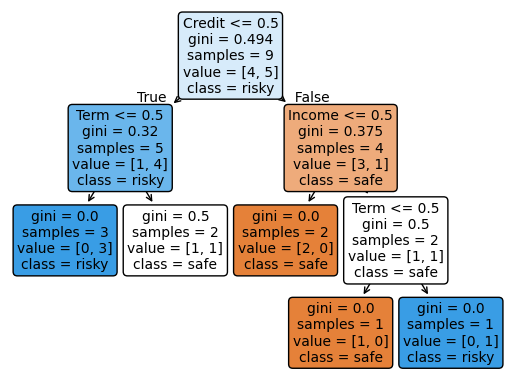

In [ ]:
plot_tree(dt,
          feature_names = X.columns,
          class_names = y.unique(),
          filled = True,
          rounded = True,
          proportion = False,
          fontsize = 10,
          precision = 3)
plt.show()

In [ ]:
dt.score(X_transformed, y)

0.8888888888888888

In [ ]:
dt.feature_importances_

array([0.39032258, 0.46451613, 0.14516129])

In [ ]:
dt.feature_importances_

array([0.39032258, 0.46451613, 0.14516129])

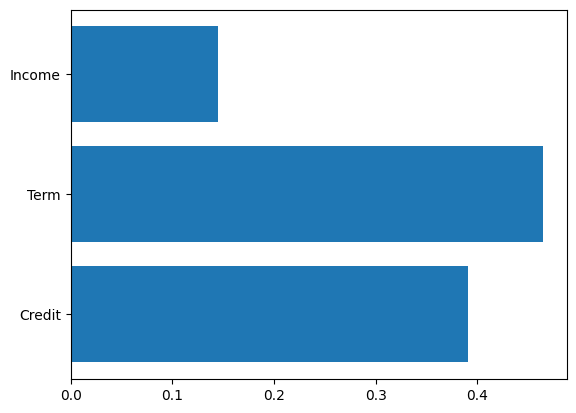

In [ ]:
plt.barh(X.columns, dt.feature_importances_)
plt.show()

#### What happens if a feature in a classification problem is ordinal with > 2 classes or a numeric?

In [ ]:
%%writefile credit_data.csv
Credit,Term,Income,y
good,3 yrs,high,safe
good,5 yrs,med,risky
good,3 yrs,low,safe
poor,5 yrs,high,risky
poor,3 yrs,low,risky
good,5 yrs,med,safe
poor,3 yrs,low,risky
poor,5 yrs,med,safe
good,3 yrs,high,safe

Writing credit_data.csv


In [ ]:
new_data = pd.read_csv('/content/credit_data.csv')
new_data.head()

,Credit,Term,Income,y
0,good,3 yrs,high,safe
1,good,5 yrs,med,risky
2,good,3 yrs,low,safe
3,poor,5 yrs,high,risky
4,poor,3 yrs,low,risky


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
oe = OrdinalEncoder(categories = [['low', 'med', 'high']]).set_output(transform = 'pandas')
oe

OrdinalEncoder(categories=[['low', 'med', 'high']])

In [ ]:
new_data['Income'] = oe.fit_transform(new_data[['Income']])
new_data.head()

,Credit,Term,Income,y
0,good,3 yrs,2.0,safe
1,good,5 yrs,1.0,risky
2,good,3 yrs,0.0,safe
3,poor,5 yrs,2.0,risky
4,poor,3 yrs,0.0,risky


In [ ]:
new_data.groupby(['Income', 'y'])['y'].count().unstack()

y,risky,safe
Income,,
0.0,2,1
1.0,1,2
2.0,1,2


In [ ]:
X = new_data.drop(['Credit', 'Term', 'y'], axis = 1)
X

,Income
0,2.0
1,1.0
2,0.0
3,2.0
4,0.0
5,1.0
6,0.0
7,1.0
8,2.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
le

LabelEncoder()

In [ ]:
new_data['y'] = le.fit_transform(new_data['y'])
new_data.head()

,Credit,Term,Income,y
0,good,3 yrs,2.0,1
1,good,5 yrs,1.0,0
2,good,3 yrs,0.0,1
3,poor,5 yrs,2.0,0
4,poor,3 yrs,0.0,0


In [ ]:
target = new_data['y']
target.head()

,y
0,1
1,0
2,1
3,0
4,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
dt = DecisionTreeClassifier()
dt

DecisionTreeClassifier()

In [ ]:
dt.fit(X, target)

DecisionTreeClassifier()

In [ ]:
import matplotlib.pyplot as plt

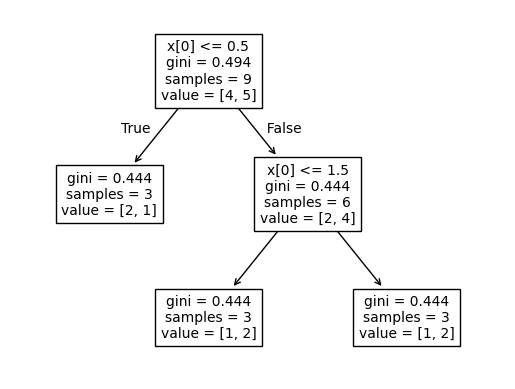

In [ ]:
plot_tree(dt, fontsize = 10)
plt.show()

#### What happens if a feature in a classification problem is Numerical?

#### Predictions with Decision Trees

- Once a decision tree model is learned from data, making predictions for new inputs is straightforward.
- **Prediction process:**  
  Given an input $ x_i $ (e.g., credit = poor, income = high, term = 5 years), the model **traverses the tree** from the root node down to a leaf node following branches that match the input’s feature values.
- At each node:
  - If it’s a **leaf node**, return the prediction stored there (e.g., “Safe” or “Risky”).
  - If it’s not a leaf, select the child node corresponding to the input’s feature value and **recurse**.
- This traversal continues recursively until a leaf is reached, which provides the predicted label $ \hat{y}_i $.
- The prediction algorithm is thus a simple recursive function that follows the decision paths shaped by the learned tree structure.

In [ ]:
query = np.array([['poor', '5 yrs', 'high']])
query

array([['poor', '5 yrs', 'high']], dtype='<U5')

In [ ]:
query_transformed = oe.transform(query)
query_transformed

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


array([[1., 1., 0.]])

In [ ]:
dt.predict(query_transformed)

array(['risky'], dtype=object)

#### Pruning

In [ ]:
path = dt.cost_complexity_pruning_path(X_transformed, y)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
ccp_alphas, impurities

(array([0.        , 0.06666667, 0.08333333, 0.14938272]),
 array([0.11111111, 0.17777778, 0.34444444, 0.49382716]))

In [ ]:
4/27

0.14814814814814814

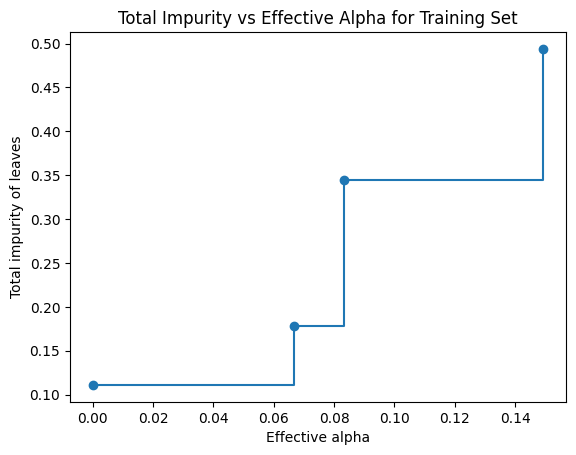

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(ccp_alphas, impurities, marker="o", drawstyle="steps-post")
plt.xlabel("Effective alpha")
plt.ylabel("Total impurity of leaves")
plt.title("Total Impurity vs Effective Alpha for Training Set")
plt.show()

In [ ]:
dt_lst = []
for alpha in ccp_alphas:
  dt = DecisionTreeClassifier(ccp_alpha=alpha)
  dt.fit(X_transformed, y)
  dt_lst.append(dt)

In [ ]:
scores_ccp_alpha = [tree.score(X_transformed, y) for tree in dt_lst]
scores_ccp_alpha

[0.8888888888888888,
 0.8888888888888888,
 0.7777777777777778,
 0.5555555555555556]

## Problem: Regression using Decision tree

The **problem** here is to **predict the selling price of a car based on various features** that describe the car’s characteristics and condition.

### Dataset Characteristics:
- **Target Variable:** Car price (continuous numeric value to be predicted, in 1000's).
- **Numerical Features:** Distance (in 1000's), Year, Engine Size, Car Weight, Income, Age, etc.
- **Categorical Features:** Brand, Transmission type, Education, Marital Status (in synthetic examples).
- Diverse attributes affecting car value including performance, condition, and buyer demographics.

### Problem Description:
- The task is a **regression problem**, where the goal is to model the relationship between input features and the continuous target variable (price).
- The target depends on many factors, some numeric (e.g., mileage, year) and some categorical (e.g., brand, transmission).
- There can be **non-linear relationships** and complex interactions between features.

In [ ]:
%%writefile car_sale_data.csv
Distance,"Year","Brand","Engine_Size","Car_Weight","Price"
30,2019,"Toyota",2.0,1500,20
45,2018,"Ford",1.8,1400,15
20,2019,"Toyota",3.0,1600,35
60,2018,"Toyota",2.2,1550,13
15,2019,"Ford",1.6,1350,22
70,2019,"Ford",3.2,1650,18
40,2018,"Toyota",2.1,1520,17

Writing car_sale_data.csv


In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/car_sale_data.csv')
data

,Distance,Year,Brand,Engine_Size,Car_Weight,Price
0,30,2019,Toyota,2.0,1500,20
1,45,2018,Ford,1.8,1400,15
2,20,2019,Toyota,3.0,1600,35
3,60,2018,Toyota,2.2,1550,13
4,15,2019,Ford,1.6,1350,22
5,70,2019,Ford,3.2,1650,18
6,40,2018,Toyota,2.1,1520,17


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Distance     7 non-null      int64  
 1   Year         7 non-null      int64  
 2   Brand        7 non-null      object 
 3   Engine_Size  7 non-null      float64
 4   Car_Weight   7 non-null      int64  
 5   Price        7 non-null      int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 468.0+ bytes


In [ ]:
data.columns

Index(['Distance', 'Year', 'Brand', 'Engine_Size', 'Car_Weight', 'Price'], dtype='object')

When calculating **Mean Squared Error (MSE) for a categorical variable in decision tree regression**, the key points are:

- Decision trees handle categorical variables by splitting the dataset into groups based on the categories.
- To calculate MSE for a split on a categorical feature:
  - Partition the data into groups based on categories (or subsets of categories).
  - For each group, calculate the mean of the target values.
  - Compute the squared deviations of each target value from its group mean.
  - Calculate the weighted average of these squared errors across all groups.

Formally, if a categorical feature splits the data into $k$ groups:

$$
\text{MSE}_{split} = \sum_{i=1}^k \frac{n_i}{n} \cdot \frac{1}{n_i} \sum_{j=1}^{n_i} (y_{ij} - \bar{y_i})^2
$$

where:
- $n_i$ is the number of samples in group $i$,
- $n$ is total samples,
- $y_{ij}$ is the target value for sample $j$ in group $i$,
- $\bar{y_i}$ is the mean target value of group $i$.

The goal is to find a split that minimizes this weighted MSE.

Since categorical features can have many possible binary splits (sets of categories), decision trees often evaluate all separations efficiently, sometimes using **mean target encoding**—ordering categories by target mean and testing splits accordingly.

In [ ]:
mse_before = data['Price'].var(ddof = 0)
mse_before

45.142857142857146

In [ ]:
def mse_after(data, feature, target):
  prob = data[feature].value_counts(normalize = True).sort_index()
  mse = data.groupby(feature)[target].var(ddof = 0)
  total_mse = prob*mse
  total_mse = total_mse.sum()
  return total_mse

In [ ]:
mse_after(data, 'Brand', 'Price')

np.float64(43.05952380952381)

In [ ]:
mse_after(data, 'Year', 'Price')

np.float64(26.392857142857146)

In [ ]:
def mse_after_num(data, feature, target):
  lst = []
  sort_data = data.sort_values([feature])
  for i in range(sort_data.shape[0]-1):
    lst.append((sort_data[feature][:i+1].iloc[-1], sort_data[feature][i+1:].iloc[0], len(sort_data[target][:i+1])/len(sort_data[target])*sort_data[target][:i+1].var(ddof = 0) + len(sort_data[target][i+1:])/len(sort_data[target])*sort_data[target][i+1:].var(ddof = 0)))
  print(pd.DataFrame(lst))
  return pd.DataFrame(lst).sort_values(2).iloc[0, -1], pd.DataFrame(lst).sort_values(2).iloc[0, :-1].mean()

In [ ]:
mse_after_num(data, 'Distance', 'Price')

    0   1          2
0  15  20  44.476190
1  20  30  16.242857
2  30  40  21.059524
3  40  45  28.809524
4  45  60  37.042857
5  60  70  44.476190


(np.float64(16.242857142857144), np.float64(25.0))

In [ ]:
mse_after_num(data, 'Engine_Size', 'Price')

(np.float64(28.242857142857144), np.float64(2.6))

In [ ]:
mse_after_num(data, 'Car_Weight', 'Price')

(np.float64(28.242857142857144), np.float64(1575.0))

In [ ]:
data_distl25 = data[data['Distance'] < 25]
data_distl25

,Distance,Year,Brand,Engine_Size,Car_Weight,Price
2,20,2019,Toyota,3.0,1600,35
4,15,2019,Ford,1.6,1350,22


In [ ]:
mse_before = data_distl25['Price']. var(ddof = 0)
mse_before

42.25

In [ ]:
mse_after(data_distl25, 'Brand', 'Price')

np.float64(0.0)

In [ ]:
mse_after(data_distl25, 'Year', 'Price')

np.float64(42.25)

In [ ]:
mse_after_num(data_distl25, 'Distance', 'Price')

(np.float64(0.0), np.float64(17.5))

In [ ]:
mse_after_num(data_distl25, 'Engine_Size', 'Price')

(np.float64(0.0), np.float64(2.3))

In [ ]:
mse_after_num(data_distl25, 'Car_Weight', 'Price')

(np.float64(0.0), np.float64(1475.0))

In [ ]:
data_distg25 = data[data['Distance'] > 25]
data_distg25

,Distance,Year,Brand,Engine_Size,Car_Weight,Price
0,30,2019,Toyota,2.0,1500,20
1,45,2018,Ford,1.8,1400,15
3,60,2018,Toyota,2.2,1550,13
5,70,2019,Ford,3.2,1650,18
6,40,2018,Toyota,2.1,1520,17


In [ ]:
mse_before = data_distg25['Price']. var(ddof = 0)
mse_before

5.840000000000001

In [ ]:
mse_after(data_distg25, 'Brand', 'Price')

np.float64(5.833333333333333)

In [ ]:
mse_after(data_distg25, 'Year', 'Price')

np.float64(2.0)

In [ ]:
mse_after_num(data_distg25, 'Distance', 'Price')

(np.float64(2.95), np.float64(35.0))

In [ ]:
mse_after_num(data_distg25, 'Engine_Size', 'Price')

(np.float64(5.033333333333333), np.float64(2.1500000000000004))

In [ ]:
mse_after_num(data_distg25, 'Car_Weight', 'Price')

(np.float64(5.033333333333333), np.float64(1535.0))

In [ ]:
data_distg25_year_2018 = data_distg25[data_distg25['Year'] == 2018]
data_distg25_year_2018

,Distance,Year,Brand,Engine_Size,Car_Weight,Price
1,45,2018,Ford,1.8,1400,15
3,60,2018,Toyota,2.2,1550,13
6,40,2018,Toyota,2.1,1520,17


In [ ]:
mse_before = data_distg25_year_2018['Price']. var(ddof = 0)
mse_before

2.6666666666666665

In [ ]:
mse_after(data_distg25_year_2018, 'Brand', 'Price')

np.float64(2.6666666666666665)

In [ ]:
mse_after(data_distg25_year_2018, 'Year', 'Price')

np.float64(2.6666666666666665)

In [ ]:
mse_after_num(data_distg25_year_2018, 'Distance', 'Price')

(np.float64(0.6666666666666666), np.float64(42.5))

In [ ]:
mse_after_num(data_distg25_year_2018, 'Engine_Size', 'Price')

(np.float64(0.6666666666666666), np.float64(2.1500000000000004))

In [ ]:
mse_after_num(data_distg25_year_2018, 'Car_Weight', 'Price')

(np.float64(0.6666666666666666), np.float64(1535.0))

In [ ]:
data_distg25_year_2019 = data_distg25[data_distg25['Year'] == 2019]
data_distg25_year_2019

,Distance,Year,Brand,Engine_Size,Car_Weight,Price
0,30,2019,Toyota,2.0,1500,20
5,70,2019,Ford,3.2,1650,18


In [ ]:
mse_before = data_distg25_year_2019['Price']. var(ddof = 0)
mse_before

1.0

In [ ]:
mse_after(data_distg25_year_2019, 'Brand', 'Price')

np.float64(0.0)

In [ ]:
mse_after(data_distg25_year_2019, 'Year', 'Price')

np.float64(1.0)

In [ ]:
mse_after_num(data_distg25_year_2019, 'Distance', 'Price')

(np.float64(0.0), np.float64(50.0))

In [ ]:
mse_after_num(data_distg25_year_2019, 'Engine_Size', 'Price')

(np.float64(0.0), np.float64(2.6))

In [ ]:
mse_after_num(data_distg25_year_2019, 'Car_Weight', 'Price')

(np.float64(0.0), np.float64(1575.0))

In [ ]:
oe = OrdinalEncoder()
oe

OrdinalEncoder()

In [ ]:
oe.fit_transform(data.select_dtypes('object'))

array([[1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.]])

In [ ]:
data[['Year', 'Brand']] = oe.fit_transform(data[['Year', 'Brand']])
data.head()

,Distance,Year,Brand,Engine_Size,Car_Weight,Price
0,30,1.0,1.0,2.0,1500,20
1,45,0.0,0.0,1.8,1400,15
2,20,1.0,1.0,3.0,1600,35
3,60,0.0,1.0,2.2,1550,13
4,15,1.0,0.0,1.6,1350,22


In [ ]:
X = data.drop('Price', axis = 1)
y = data['Price']

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
dtr = DecisionTreeRegressor()
dtr

DecisionTreeRegressor()

In [ ]:
dtr.fit(X, y)

DecisionTreeRegressor()

In [ ]:
data

,Distance,Year,Brand,Engine_Size,Car_Weight,Price
0,30,1.0,1.0,2.0,1500,20
1,45,0.0,0.0,1.8,1400,15
2,20,1.0,1.0,3.0,1600,35
3,60,0.0,1.0,2.2,1550,13
4,15,1.0,0.0,1.6,1350,22
5,70,1.0,0.0,3.2,1650,18
6,40,0.0,1.0,2.1,1520,17


In [ ]:
sort_data = data.sort_values('Distance')
sort_data

,Distance,Year,Brand,Engine_Size,Car_Weight,Price
4,15,1.0,0.0,1.6,1350,22
2,20,1.0,1.0,3.0,1600,35
0,30,1.0,1.0,2.0,1500,20
6,40,0.0,1.0,2.1,1520,17
1,45,0.0,0.0,1.8,1400,15
3,60,0.0,1.0,2.2,1550,13
5,70,1.0,0.0,3.2,1650,18


In [ ]:
sort_data.iloc[:6, 5].var(ddof = 0), sort_data.iloc[6:, 5].var(ddof = 0)

(51.88888888888889, 0.0)

In [ ]:
(6/7)*sort_data.iloc[:6, 5].var(ddof = 0)+(1/7)*sort_data.iloc[6:, 5].var(ddof = 0)

44.476190476190474

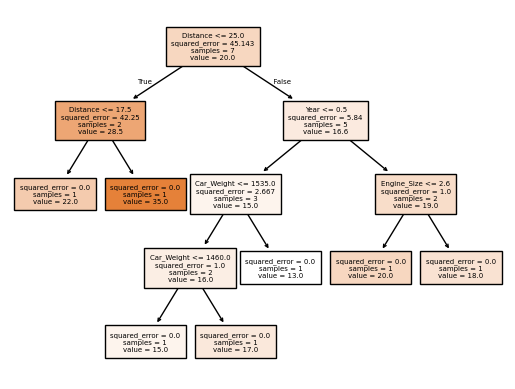

In [ ]:
plot_tree(dtr, feature_names=X.columns, filled = True, fontsize = 5)
plt.show()

## Pruning

In [ ]:
path = dt.cost_complexity_pruning_path(X, y)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
ccp_alphas, impurities

(array([0.        , 0.14285714]), array([0.        , 0.85714286]))

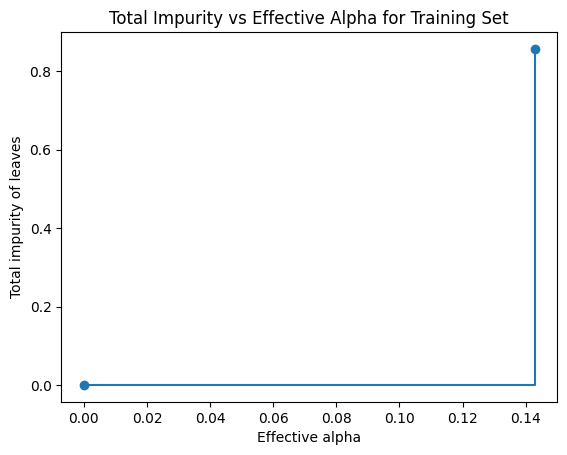

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(ccp_alphas, impurities, marker="o", drawstyle="steps-post")
plt.xlabel("Effective alpha")
plt.ylabel("Total impurity of leaves")
plt.title("Total Impurity vs Effective Alpha for Training Set")
plt.show()

### Advantages of Decision Tree Models

1. **Predictions are easily interpretable**
- Decision trees are very intuitive and resemble human decision-making.
- A prediction is obtained by simply following a path of “if–then” rules down the tree.
- This makes it easy to explain predictions to non-technical stakeholders (e.g., explaining why a loan application was approved or rejected).
- Unlike many “black-box” models (like neural networks), decision trees provide transparency.

2. **Versatility in handling different types of data**
- Decision trees do not impose assumptions on the type of input features.
- They can handle:
  - Numeric data (e.g., age, income, temperature),
  - Categorical data (e.g., gender, color, type),
  - Boolean data (e.g., yes/no),
  - Even textual attributes (after simple preprocessing).
- This flexibility makes decision trees suitable for a wide variety of real-world datasets.

3. **Scale-invariance and robustness to multicollinearity**
- Unlike algorithms such as logistic regression or k-means clustering, decision trees do not require normalization or standardization of data.
- This is because the tree only needs to compare values within the same feature when deciding a split, rather than relying on magnitude or scale.
- Decision trees are also relatively robust against multicollinearity (when two features are highly correlated), because the tree will typically pick the more informative feature first.


4. **Feature importance**
- Decision trees provide insights into the relative importance of features in predicting the target variable.
- Features that are used at the top levels of the tree (early splits) tend to be the most influential.
- This information is valuable for feature selection, interpretability, and understanding underlying data patterns.

5. **Efficiency and speed**
- Decision trees are computationally efficient to build.
- The splitting process is relatively fast compared to iterative algorithms like gradient descent.
- Once trained, predictions are very quick, as they only involve traversing a path from the root node to a leaf node.

6. **Ability to capture complex, non-linear relationships**
- Decision trees are not restricted to linear decision boundaries.
- They can capture non-linear patterns between features and the target variable.
- For regression tasks, decision trees can approximate highly complex functions by splitting the data space into smaller, more homogeneous regions.
- Example: If house price depends on income in one range and location in another, a regression tree can adaptively model this relationship, unlike simple linear regression.

7. **Handle multiclass classification**

- Decision trees naturally support multiclass classification problems, so there is no need to break them into multiple one-vs-rest binary classifiers.
- The tree uses impurity measures such as entropy or mean squared error to evaluate splits, which are effective with several class labels.
- When making predictions, the tree assigns a data point to the class most commonly found among samples in the corresponding leaf node—using a majority vote among all possible classes, just as with binary classification.

8. **Handle mising values**

### Limitations of Decision Trees
1. **Overfitting:**
- If grown without restrictions, a decision tree continues splitting until it classifies all training points perfectly.
- This leads to the model “memorizing” the training data rather than generalizing.
2. **Instability:**
- Decision trees are highly sensitive to small changes in data.
- Even slight variations in the dataset can produce a very different tree structure.

3. **Sensitive to Data Imbalance - Biased towards class that dominates**
-  Decision trees struggle with imbalanced datasets because impurity measures such as entropy or mean squared error tend to favor the majority class, making the tree less sensitive to minority classes.

-  This bias can cause the decision tree to overlook or ignore minority class examples during prediction.

- To address this, balance the dataset by either oversampling—adding more instances from the minority class—or undersampling—removing some samples from the majority class. This helps the model pay equal attention to all classes.
4. **Very high training time**
- It is worse if there are numerical features in input data.

5. **Sensitive to Outliers**

6. **Predictions are piecewise constant approximation**

### Why **just use a decision tree** is not always right???

Decision trees are intuitive, handle both numeric and categorical features, and produce human-readable rules. But a plain, unconstrained tree is a high-variance (or informally noise) learner: if you let it keep splitting, it will keep carving the training set into tiny pockets, overfitting noise and outliers. Small data changes can produce very different trees (instability), and test performance can drop.

- **If you just keep growing the tree deeper and deeper, ultimately each leaf narrows down to just one individual in the training data.**



#### Truncation (Pre-pruning)

Stop growth early based on user-defined limits so leaves don’t get too small or the tree too deep.

Common knobs (scikit-learn DecisionTreeClassifier):
- **criterion** = {"gini","entropy"}: impurity measure used to pick splits.
- **max_features**: number of features to consider per split (None, integer, fraction, "sqrt", "log2").
- **max_depth**: maximum depth of the tree.
- **min_samples_split**: minimum samples required to split a node.
- **min_samples_leaf**: minimum samples required in any leaf.
- **max_leaf_nodes**: cap total leaves (forces best-first growth).
- **min_impurity_decrease**: split only if impurity decrease ≥ this threshold.

Mapping to **methods of truncation**
1. Limit min partition size after a split → **min_samples_split**
2. Limit depth → **max_depth**
3. Minimum samples in a leaf → **min_samples_leaf**
4. Limit # leaves → **max_leaf_nodes**
5. Minimize change in homogeneity (require a minimum gain) → **min_impurity_decrease**

#### Pruning (Post-pruning): Balance Fit and Complexity

- As the tree gets deeper, the error in the training data decreases, but the error in the test data may increase. — overfitting
- To prevent overfitting of the decision tree, branches of the complex tree are pruned to create a less complex tree. — pruning
- Initially, the tree is constructed complex enough to have no misclassification cases at the leaf nodes, and then unnecessary branches are pruned. - post pruning
- CCP is a pruning algorithm proposed by Breiman, Stone, and Olsen when they introduced CART in 1984.
- Grow first, then cut back from the bottom. In scikit-learn this is implemented as **cost-complexity pruning via ccp_alpha**. Increasing ccp_alpha penalizes tree size; branches that don’t pull their weight (in impurity reduction) get snipped.

In practice, post-pruning often generalizes better because the tree has the chance to consider complex interactions before we simplify it.

- A very deep tree can fit the training data almost perfectly, but will usually overfit and generalize poorly.  
- A very shallow tree may be too simple and underfit.  
- The goal is to find a tree that:
  - Fits the training data reasonably well, and  
  - Is as simple as possible.

This is expressed with a **total cost**:

$$
\text{Cost}(T) = \text{Error}(T) + \lambda \cdot L(T)
$$

Where:
- $\text{Error}(T)$: training classification error (how badly the tree fits the data).  
- $L(T)$: number of leaves in the tree (a simple measure of complexity).  
- $\lambda \ge 0$: regularization parameter controlling the tradeoff.

Interpretation:
- Large $\text{Error}(T)$ → tree does not fit the data well.  
- Large $L(T)$ → tree is complex and likely to overfit.  
- $\lambda$ tunes how much you care about simplicity vs fit:
  - $\lambda = 0$: only care about fit → you get a very large tree.  
  - $\lambda \to \infty$: only care about simplicity → you get a stump (single root predicting the majority class).  
  - Intermediate $\lambda$: gives a reasonably sized, well-generalizing tree.

**Decision Tree Pruning Algorithm - Bottom-Up Traversal**

```
Algorithm: PRUNE_TREE(T, λ)
1. Start at bottom of tree T
2. Traverse upward to root
3. For each decision node M:
   • Apply PRUNE_SPLIT(T, M)
```

```
PRUNE_SPLIT(T, M):
1. Compute current tree cost:
   C(T) = Error(T) + λ × L(T)
   
2. Create pruned candidate T_smaller:
   • Replace subtree below node M with single leaf
   • Leaf = majority class of that subtree region
   
3. Compute pruned tree cost:
   C(T_smaller) = Error(T_smaller) + λ × L(T_smaller)
   
4. Pruning decision:
   IF C(T_smaller) < C(T):
      • Set T = T_smaller (prune subtree)
      • Continue upward
   ELSE:
      • Keep original subtree
```

```
Error(T): Training classification error
L(T):     Number of leaves (tree complexity)
λ:        Regularization parameter
T_smaller: Tree after pruning subtree at M
```

#### Practical guidance
- Start with pre-pruning: tune max_depth and min_samples_leaf.
- If you still see overfitting or want a principled simplification, tune ccp_alpha for post-pruning.
- Avoid excessive one-hot encoding with very high-cardinality categoricals (explodes feature space and training time). Consider target encoding, hashing, or tree models that natively handle categories (e.g., CatBoost) when appropriate.
- For best accuracy on complex problems, use ensembles (Random Forests, Gradient-Boosted Trees/XGBoost/LightGBM/CatBoost). They drastically reduce variance vs a single tree.

**What you should observe (typical pattern)?**
- The unconstrained tree has high depth and many leaves, very high train accuracy, but lower test accuracy (overfit).
- The pre-pruned tree has smaller depth and fewer leaves; slightly lower train accuracy but better generalization.
- The post-pruned tree, after tuning ccp_alpha, often matches or beats the pre-pruned test accuracy with a compact structure.

**When to prefer pre-pruning vs post-pruning?**
- Pre-pruning reduces training time (fewer splits explored), gives you a simple model quickly, and is easy to reason about (e.g., “never go deeper than 6”, “leaves must have ≥ 20 samples”).
- Post-pruning lets the tree fully explore interactions, then removes weak branches. It often yields cleaner bias–variance trade-offs, especially with ccp_alpha tuned by CV.